In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 

In [2]:
df = pd.read_csv('Cancer_Data.csv')

In [3]:
#df = df.drop(columns=['Unnamed: 32'], axis=1)
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [6]:
#convert Malign and beneign into 1 and 0

df['diagnosis_0_1'] = df['diagnosis'].map({'M':1, 'B':0})
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32,diagnosis_0_1
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN,1
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN,1
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN,1
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN,1
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN,1


<Axes: xlabel='diagnosis', ylabel='count'>

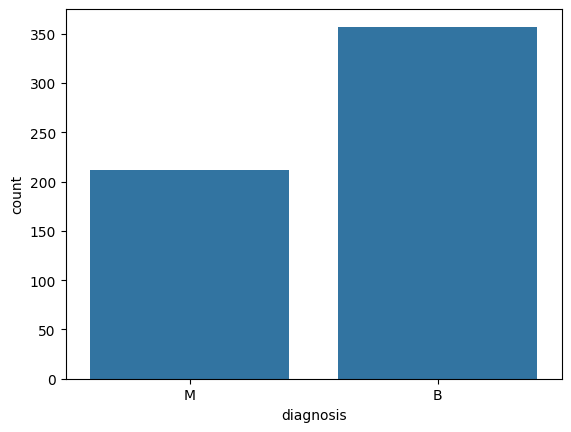

In [7]:
sns.countplot(df, x = 'diagnosis')

<Axes: xlabel='diagnosis_0_1', ylabel='count'>

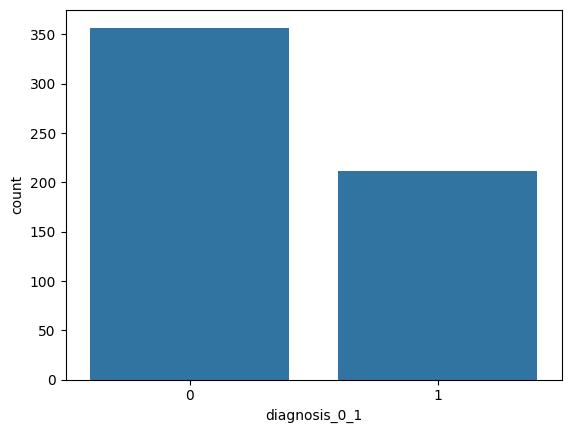

In [8]:
sns.countplot(df, x = 'diagnosis_0_1')

In [9]:
df = df.drop(['diagnosis'], axis=1)

In [10]:
df.head()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32,diagnosis_0_1
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN,1
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN,1
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN,1
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN,1
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN,1


<Axes: >

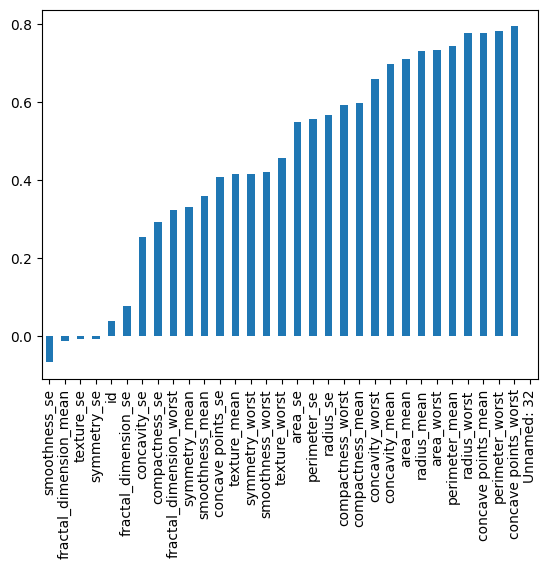

In [11]:
df.corr()['diagnosis_0_1'][:-1].sort_values().plot(kind='bar')

In [12]:
#lets drop id 
df = df.drop(['id'], axis=1)

In [13]:
#dropping the null column
df = df.drop(['Unnamed: 32'], axis=1)

In [14]:
X = df.drop('diagnosis_0_1', axis=1).values
y = df['diagnosis_0_1'].values

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
train_test_split = X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)

In [17]:
from sklearn.preprocessing import MinMaxScaler

In [18]:
scaler = MinMaxScaler()

In [19]:
X_train = scaler.fit_transform(X_train)

In [20]:
X_test = scaler.transform(X_test)

In [21]:
from tensorflow.keras.models import Sequential

In [24]:
from tensorflow.keras.layers import Dense, Dropout

In [26]:
X_train.shape #it means that we have 30 features(columns), so we will have 30 initial input in out NN

(426, 30)

In [29]:
model = Sequential()

model.add(Dense(30, activation='relu'))

model.add(Dense(15, activation='relu'))

#Binary classification, sigmoid function gives us output in between in 1 and 0
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam')          

In [31]:
model.fit(x=X_train, y=y_train, epochs=600, validation_data=(X_test, y_test))

Epoch 1/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.6819 - val_loss: 0.6596
Epoch 2/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.6429 - val_loss: 0.6155
Epoch 3/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.5916 - val_loss: 0.5548
Epoch 4/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.5333 - val_loss: 0.4955
Epoch 5/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.4786 - val_loss: 0.4427
Epoch 6/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.4333 - val_loss: 0.3948
Epoch 7/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.3730 - val_loss: 0.3524
Epoch 8/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.3356 - val_loss: 0.3156
Epoch 9/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.3079 - val_loss: 0.2862
Epoch 10/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2953 - val_loss: 0.2593
Epoch 11/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2486 - val_loss: 0.2393
Epoch 12/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

In [32]:
losses = pd.DataFrame(model.history.history)

In [33]:
losses.head()

,loss,val_loss
0,0.676141,0.659579
1,0.635711,0.615482
2,0.579514,0.554780
3,0.521976,0.495549
4,0.470135,0.442722


<Axes: >

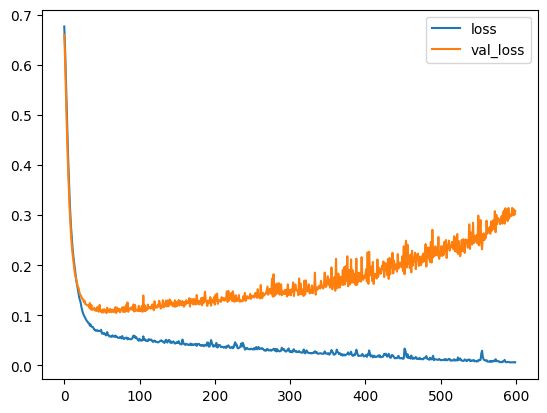

In [35]:
losses.plot() #Validation loss is going up, training loss is going down. it means that model is overfitting

In [36]:
# Okay, out loss history is clearly screaming that we are overfitting.
# to solve this problem we will use Early stopping method and  we will redifine our model

model = Sequential()

model.add(Dense(30, activation='relu'))

model.add(Dense(15, activation='relu'))

#Binary classification, sigmoid function gives us output in between in 1 and 0
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam')          

In [37]:
from tensorflow.keras.callbacks import EarlyStopping

In [38]:
help(EarlyStopping)

Help on class EarlyStopping in module keras.src.callbacks.early_stopping:

class EarlyStopping(keras.src.callbacks.callback.Callback)
 |  EarlyStopping(monitor='val_loss', min_delta=0, patience=0, verbose=0, mode='auto', baseline=None, restore_best_weights=False, start_from_epoch=0)
 |  
 |  Stop training when a monitored metric has stopped improving.
 |  
 |  Assuming the goal of a training is to minimize the loss. With this, the
 |  metric to be monitored would be `'loss'`, and mode would be `'min'`. A
 |  `model.fit()` training loop will check at end of every epoch whether
 |  the loss is no longer decreasing, considering the `min_delta` and
 |  `patience` if applicable. Once it's found no longer decreasing,
 |  `model.stop_training` is marked True and the training terminates.
 |  
 |  The quantity to be monitored needs to be available in `logs` dict.
 |  To make it so, pass the loss or metrics at `model.compile()`.
 |  
 |  Args:
 |      monitor: Quantity to be monitored. Defaults 

In [39]:
early_stop= EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=25)

In [40]:
model.fit(x=X_train, y=y_train, epochs=600, validation_data=(X_test, y_test), callbacks=[early_stop])

Epoch 1/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.6767 - val_loss: 0.6405
Epoch 2/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.6200 - val_loss: 0.5931
Epoch 3/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.5752 - val_loss: 0.5443
Epoch 4/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.5219 - val_loss: 0.4940
Epoch 5/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.4733 - val_loss: 0.4424
Epoch 6/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.4236 - val_loss: 0.3939
Epoch 7/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.3810 - val_loss: 0.3528
Epoch 8/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.3415 - val_loss: 0.3171
Epoch 9/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3068 - val_loss: 0.2915
Epoch 10/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2878 - val_loss: 0.2651
Epoch 11/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2654 - val_loss: 0.2451
Epoch 12/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

In [41]:
losses = pd.DataFrame(model.history.history)

<Axes: >

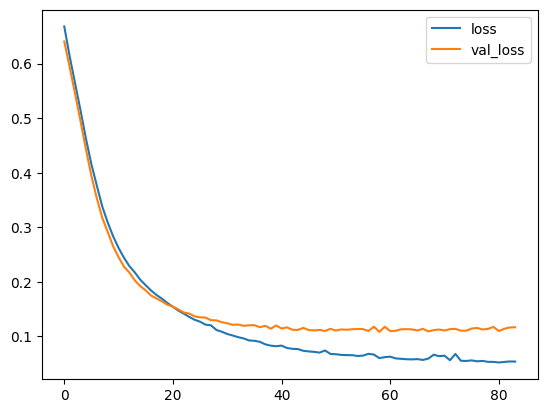

In [42]:
losses.plot()

In [43]:
#Okay now to prevent overfitting further, what we can do is add drop out layers
#drop out layers can drop nuerons at random in hidden layer which will generate more unbiased features.
from tensorflow.keras.layers import Dropout

In [44]:
model = Sequential()

model.add(Dense(30, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(15, activation='relu'))
model.add(Dropout(0.5))

#Binary classification, sigmoid function gives us output in between in 1 and 0
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam')          

In [45]:
model.fit(x=X_train, y=y_train, epochs=600, validation_data=(X_test, y_test), callbacks=[early_stop])

Epoch 1/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.7797 - val_loss: 0.6938
Epoch 2/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7076 - val_loss: 0.6573
Epoch 3/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6542 - val_loss: 0.6287
Epoch 4/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6682 - val_loss: 0.6031
Epoch 5/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6556 - val_loss: 0.5835
Epoch 6/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6076 - val_loss: 0.5578
Epoch 7/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5881 - val_loss: 0.5331
Epoch 8/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5578 - val_loss: 0.5068
Epoch 9/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5632 - val_loss: 0.4801
Epoch 10/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5029 - val_loss: 0.4524
Epoch 11/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4894 - val_loss: 0.4218
Epoch 12/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0

In [46]:
losses = pd.DataFrame(model.history.history)

<Axes: >

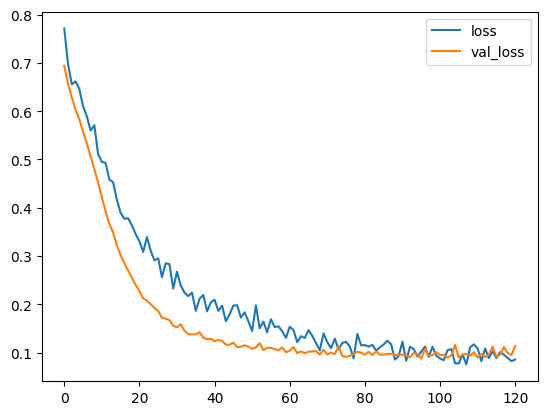

In [48]:
losses.plot() #this is the best behavior we can expect. loss and val_loss both are going down and get flatten at the end.

In [52]:
#Lets do evaluation
predictions = (model.predict(X_test) > 0.5).astype("int32")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


In [53]:
from sklearn.metrics import classification_report, confusion_matrix

In [54]:
print(classification_report(predictions, y_test))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        86
           1       0.98      0.95      0.96        57

    accuracy                           0.97       143
   macro avg       0.97      0.97      0.97       143
weighted avg       0.97      0.97      0.97       143



In [55]:
print(confusion_matrix(predictions, y_test))

[[85  1]
 [ 3 54]]


In [56]:
#our NN model have now 97% accuracy